In [4]:
import glob
from pathlib import Path

import pandas as pd


files_pattern = r"D:\haui_sict_fitness_score\recognize_block\frame_*_final_metrics.csv"
worker_concurrency = 2

files = sorted(glob.glob(files_pattern))

if not files:
    raise FileNotFoundError(f"Không tìm thấy file theo pattern: {files_pattern}")

dfs = []

for file in files:
    path = Path(file)

    df = pd.read_csv(path)

    required_cols = {"frame_id", "time_seconds", "status"}

    # Nếu file không có header thì đọc lại theo 3 cột chuẩn
    if not required_cols.issubset(set(df.columns)):
        df = pd.read_csv(
            path,
            header=None,
            names=["frame_id", "time_seconds", "status"],
        )

    cam_id = path.name.replace("frame_", "").replace("_final_metrics.csv", "")

    df["cam_id"] = cam_id
    df["source_file"] = path.name
    df["frame_id"] = pd.to_numeric(df["frame_id"], errors="coerce")
    df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")
    df["status"] = df["status"].astype(str)

    df = df.dropna(subset=["frame_id", "time_seconds"])
    df["frame_id"] = df["frame_id"].astype(int)

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# 1. Toàn bộ CSV chạy được bao nhiêu FPS
total_frames = len(all_df)
total_time_seconds = all_df["time_seconds"].sum()
avg_all_time = all_df["time_seconds"].mean()
all_fps = total_frames / total_time_seconds if total_time_seconds > 0 else 0

# 2. Các frame đi qua consumer được bao nhiêu FPS
processed_df = all_df[all_df["status"] == "processed"]

processed_frames = len(processed_df)
processed_total_time = processed_df["time_seconds"].sum()
processed_avg_time = processed_df["time_seconds"].mean()
processed_equivalent_fps = (
    processed_frames / processed_total_time
    if processed_total_time > 0
    else 0
)

# 3. Ước lượng consumer 2 luồng
estimated_consumer_capacity_fps = (
    worker_concurrency / processed_avg_time
    if processed_avg_time and processed_avg_time > 0
    else 0
)

print("===== OVERALL REPORT =====")
print(f"Số file CSV                      : {len(files)}")
print(f"Tổng số frame                    : {total_frames}")
print(f"Tổng thời gian cộng dồn          : {total_time_seconds:.6f} giây")
print(f"Thời gian trung bình / frame     : {avg_all_time:.6f} giây")
print(f"FPS toàn bộ CSV                  : {all_fps:.3f} FPS")

print("\n===== PROCESSED FRAME REPORT =====")
print(f"Số frame qua consumer            : {processed_frames}")
print(f"Tổng thời gian processed cộng dồn: {processed_total_time:.6f} giây")
print(f"Thời gian TB / processed frame   : {processed_avg_time:.6f} giây")
print(f"Processed equivalent FPS         : {processed_equivalent_fps:.3f} FPS")

print("\n===== CONSUMER 2-LUỒNG ƯỚC LƯỢNG =====")
print(f"worker_concurrency               : {worker_concurrency}")
print(f"Estimated consumer capacity      : {estimated_consumer_capacity_fps:.3f} FPS")
print("Lưu ý: chỉ là ước lượng lý thuyết, không phải throughput thực tế nếu không có start/end timestamp.")

print("\n===== PER CAMERA =====")

summary_rows = []

for cam_id, g in all_df.groupby("cam_id"):
    g_processed = g[g["status"] == "processed"]

    cam_total_frames = len(g)
    cam_total_time = g["time_seconds"].sum()
    cam_avg_time = g["time_seconds"].mean()
    cam_all_fps = cam_total_frames / cam_total_time if cam_total_time > 0 else 0

    cam_processed_frames = len(g_processed)
    cam_processed_total_time = g_processed["time_seconds"].sum()
    cam_processed_avg_time = g_processed["time_seconds"].mean()

    cam_processed_fps = (
        cam_processed_frames / cam_processed_total_time
        if cam_processed_total_time > 0
        else 0
    )

    summary_rows.append({
        "cam_id": cam_id,
        "total_frames": cam_total_frames,
        "total_time_seconds": cam_total_time,
        "avg_time_seconds_per_frame": cam_avg_time,
        "all_frame_fps": cam_all_fps,
        "processed_frames": cam_processed_frames,
        "processed_total_time_seconds": cam_processed_total_time,
        "processed_avg_time_seconds_per_frame": cam_processed_avg_time,
        "processed_equivalent_fps": cam_processed_fps,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.to_csv("fps_summary_by_camera.csv", index=False)
all_df.to_csv("all_cameras_final_metrics.csv", index=False)

print("\nĐã ghi:")
print("- fps_summary_by_camera.csv")
print("- all_cameras_final_metrics.csv")

===== OVERALL REPORT =====
Số file CSV                      : 4
Tổng số frame                    : 114297
Tổng thời gian cộng dồn          : 15278.498966 giây
Thời gian trung bình / frame     : 0.133674 giây
FPS toàn bộ CSV                  : 7.481 FPS

===== PROCESSED FRAME REPORT =====
Số frame qua consumer            : 1118
Tổng thời gian processed cộng dồn: 427.072000 giây
Thời gian TB / processed frame   : 0.381996 giây
Processed equivalent FPS         : 2.618 FPS

===== CONSUMER 2-LUỒNG ƯỚC LƯỢNG =====
worker_concurrency               : 2
Estimated consumer capacity      : 5.236 FPS
Lưu ý: chỉ là ước lượng lý thuyết, không phải throughput thực tế nếu không có start/end timestamp.

===== PER CAMERA =====


,cam_id,total_frames,total_time_seconds,avg_time_seconds_per_frame,all_frame_fps,processed_frames,processed_total_time_seconds,processed_avg_time_seconds_per_frame,processed_equivalent_fps
0,1,28473,3697.424733,0.129857,7.700765,365,85.201,0.233427,4.283987
1,2,28608,3907.243156,0.136579,7.321786,258,142.754,0.553310,1.807305
2,3,28608,3820.278307,0.133539,7.488460,347,80.987,0.233392,4.284638
3,4,28608,3853.552770,0.134702,7.423799,148,118.130,0.798176,1.252857



Đã ghi:
- fps_summary_by_camera.csv
- all_cameras_final_metrics.csv


In [8]:
import pandas as pd

df = pd.read_csv(r"D:\haui_sict_fitness_score\recognize_block\frame_2_final_metrics.csv")

# Chuẩn hóa dữ liệu
df["status"] = df["status"].astype(str).str.strip()
df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")

# Lọc processed
processed_df = df[df["status"] == "processed"].copy()
processed_df

,frame_id,time_seconds,status
615,615,0.913,processed
620,620,0.676,processed
629,629,0.228,processed
635,635,0.188,processed
641,641,0.215,processed
...,...,...,...
26817,26817,0.152,processed
26822,26822,0.175,processed
26826,26826,0.163,processed
26840,26840,0.122,processed


In [10]:
total_time = processed_df["time_seconds"].sum()
total_time

142.754

In [11]:
for cam_id in ["1", "2", "3", "4"]:
    g = all_df[
        (all_df["cam_id"].astype(str) == cam_id)
        & (all_df["status"] == "processed")
    ].copy()

    print(f"\n===== CAM {cam_id} =====")
    print("frames:", len(g))
    print("sum:", g["time_seconds"].sum())
    print("mean:", g["time_seconds"].mean())
    print("median:", g["time_seconds"].median())
    print("p90:", g["time_seconds"].quantile(0.90))
    print("p95:", g["time_seconds"].quantile(0.95))
    print("p99:", g["time_seconds"].quantile(0.99))
    print("max:", g["time_seconds"].max())

    print("Top 10 slow frames:")
    print(
        g.sort_values("time_seconds", ascending=False)
        [["frame_id", "time_seconds", "status"]]
        .head(10)
    )


===== CAM 1 =====
frames: 365
sum: 85.201
mean: 0.23342739726027395
median: 0.236
p90: 0.322
p95: 0.37740000000000007
p99: 0.5080400000000005
max: 0.778
Top 10 slow frames:
       frame_id  time_seconds     status
451         451         0.778  processed
22655     22655         0.645  processed
1281       1281         0.592  processed
2335       2335         0.533  processed
506         506         0.494  processed
456         456         0.489  processed
460         460         0.483  processed
4393       4393         0.477  processed
512         512         0.435  processed
575         575         0.433  processed

===== CAM 2 =====
frames: 258
sum: 142.754
mean: 0.5533100775193798
median: 0.1705
p90: 0.4092
p95: 2.9214499999999735
p99: 8.255520000000004
max: 9.287
Top 10 slow frames:
       frame_id  time_seconds     status
39091     10618         9.287  processed
39095     10622         8.959  processed
39099     10626         8.634  processed
39108     10635         7.970  proces

Found files:
D:\haui_sict_fitness_score\recognize_block\frame_1_final_metrics.csv
D:\haui_sict_fitness_score\recognize_block\frame_2_final_metrics.csv
D:\haui_sict_fitness_score\recognize_block\frame_3_final_metrics.csv
D:\haui_sict_fitness_score\recognize_block\frame_4_final_metrics.csv
   cam_id  frames  median      p95       p99      mean     max  median_ms  \
0       1     365  0.2360  0.37740   0.50804  0.233427   0.778      236.0   
1       2     258  0.1705  2.92145   8.25552  0.553310   9.287      170.5   
2       3     347  0.2200  0.39640   0.48632  0.233392   1.256      220.0   
3       4     148  0.1895  5.82050  12.66437  0.798176  13.831      189.5   

    p95_ms    p99_ms  
0   377.40    508.04  
1  2921.45   8255.52  
2   396.40    486.32  
3  5820.50  12664.37  


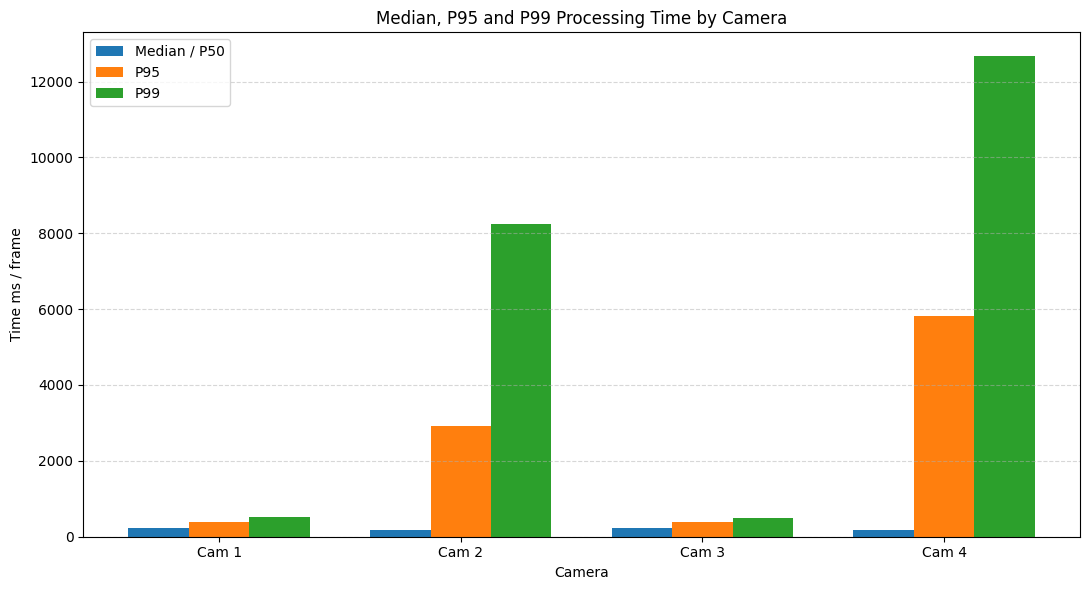

Saved chart to: D:\haui_sict_fitness_score\recognize_block\median_p95_p99_by_camera_ms.png


In [2]:
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


files_pattern = r"D:\haui_sict_fitness_score\recognize_block\frame_*_final_metrics.csv"
files = sorted(glob.glob(files_pattern))

print("Found files:")
for f in files:
    print(f)

if not files:
    raise FileNotFoundError(f"Không tìm thấy file theo pattern: {files_pattern}")

dfs = []

for file in files:
    path = Path(file)

    df = pd.read_csv(path)

    if not {"frame_id", "time_seconds", "status"}.issubset(df.columns):
        df = pd.read_csv(
            path,
            header=None,
            names=["frame_id", "time_seconds", "status"],
        )

    cam_id = path.name.replace("frame_", "").replace("_final_metrics.csv", "")

    df["cam_id"] = cam_id
    df["status"] = df["status"].astype(str).str.strip()
    df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# Chỉ lấy các frame đi qua consumer
processed_df = all_df[all_df["status"] == "processed"].copy()

summary = (
    processed_df
    .groupby("cam_id")["time_seconds"]
    .agg(
        frames="count",
        median="median",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        mean="mean",
        max="max",
    )
    .reset_index()
)

summary["cam_id"] = summary["cam_id"].astype(int)
summary = summary.sort_values("cam_id")

summary["median_ms"] = summary["median"] * 1000
summary["p95_ms"] = summary["p95"] * 1000
summary["p99_ms"] = summary["p99"] * 1000

print(summary)

x = range(len(summary))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    [i - width for i in x],
    summary["median_ms"],
    width=width,
    label="Median / P50",
)

plt.bar(
    [i for i in x],
    summary["p95_ms"],
    width=width,
    label="P95",
)

plt.bar(
    [i + width for i in x],
    summary["p99_ms"],
    width=width,
    label="P99",
)

plt.xticks(x, [f"Cam {cam}" for cam in summary["cam_id"]])
plt.xlabel("Camera")
plt.ylabel("Time ms / frame")
plt.title("Median, P95 and P99 Processing Time by Camera")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

output_path = r"D:\haui_sict_fitness_score\recognize_block\median_p95_p99_by_camera_ms.png"
plt.savefig(output_path, dpi=200)

plt.show()

print(f"Saved chart to: {output_path}")

In [1]:
import glob
from pathlib import Path

import pandas as pd


files_pattern = r"D:\haui_sict_fitness_score\recognize_block\frame_*_final_metrics.csv"

thresholds = [0.2, 0.5, 1.0]

files = sorted(glob.glob(files_pattern))

if not files:
    raise FileNotFoundError(f"Không tìm thấy file theo pattern: {files_pattern}")

dfs = []

for file in files:
    path = Path(file)

    df = pd.read_csv(path)

    # Nếu file không có header thì đọc lại
    if not {"frame_id", "time_seconds", "status"}.issubset(df.columns):
        df = pd.read_csv(
            path,
            header=None,
            names=["frame_id", "time_seconds", "status"],
        )

    cam_id = path.name.replace("frame_", "").replace("_final_metrics.csv", "")

    df["cam_id"] = cam_id
    df["frame_id"] = pd.to_numeric(df["frame_id"], errors="coerce")
    df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")
    df["status"] = df["status"].astype(str).str.strip()

    df = df.dropna(subset=["frame_id", "time_seconds"])
    df["frame_id"] = df["frame_id"].astype(int)

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

processed_df = all_df[all_df["status"] == "processed"].copy()

summary_rows = []

for cam_id, g in processed_df.groupby("cam_id"):
    total = len(g)

    row = {
        "cam_id": cam_id,
        "processed_frames": total,
        "total_time_seconds": g["time_seconds"].sum(),
        "mean_seconds": g["time_seconds"].mean(),
        "median_seconds": g["time_seconds"].median(),
        "p95_seconds": g["time_seconds"].quantile(0.95),
        "p99_seconds": g["time_seconds"].quantile(0.99),
        "max_seconds": g["time_seconds"].max(),
    }

    row["fps_by_mean"] = 1 / row["mean_seconds"] if row["mean_seconds"] > 0 else 0
    row["fps_by_median"] = 1 / row["median_seconds"] if row["median_seconds"] > 0 else 0

    for threshold in thresholds:
        count_fast = (g["time_seconds"] <= threshold).sum()
        ratio_fast = count_fast / total * 100 if total > 0 else 0

        col_prefix = str(threshold).replace(".", "_")
        row[f"frames_le_{col_prefix}s"] = count_fast
        row[f"percent_le_{col_prefix}s"] = ratio_fast

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_df["cam_id"] = summary_df["cam_id"].astype(int)
summary_df = summary_df.sort_values("cam_id")

# In kết quả dễ đọc
for _, row in summary_df.iterrows():
    print(f"\n===== CAM {int(row['cam_id'])} =====")
    print(f"Processed frames : {int(row['processed_frames'])}")
    print(f"Mean             : {row['mean_seconds']:.6f}s")
    print(f"Median           : {row['median_seconds']:.6f}s")
    print(f"P95              : {row['p95_seconds']:.6f}s")
    print(f"P99              : {row['p99_seconds']:.6f}s")
    print(f"Max              : {row['max_seconds']:.6f}s")
    print(f"FPS by mean      : {row['fps_by_mean']:.3f}")
    print(f"FPS by median    : {row['fps_by_median']:.3f}")

    for threshold in thresholds:
        col_prefix = str(threshold).replace(".", "_")
        count_col = f"frames_le_{col_prefix}s"
        percent_col = f"percent_le_{col_prefix}s"

        print(
            f"<= {threshold}s        : "
            f"{int(row[count_col])}/{int(row['processed_frames'])} "
            f"({row[percent_col]:.2f}%)"
        )

output_path = r"D:\haui_sict_fitness_score\recognize_block\processed_latency_summary.csv"
summary_df.to_csv(output_path, index=False)

print(f"\nSaved summary to: {output_path}")


===== CAM 1 =====
Processed frames : 365
Mean             : 0.233427s
Median           : 0.236000s
P95              : 0.377400s
P99              : 0.508040s
Max              : 0.778000s
FPS by mean      : 4.284
FPS by median    : 4.237
<= 0.2s        : 158/365 (43.29%)
<= 0.5s        : 361/365 (98.90%)
<= 1.0s        : 365/365 (100.00%)

===== CAM 2 =====
Processed frames : 258
Mean             : 0.553310s
Median           : 0.170500s
P95              : 2.921450s
P99              : 8.255520s
Max              : 9.287000s
FPS by mean      : 1.807
FPS by median    : 5.865
<= 0.2s        : 167/258 (64.73%)
<= 0.5s        : 235/258 (91.09%)
<= 1.0s        : 244/258 (94.57%)

===== CAM 3 =====
Processed frames : 347
Mean             : 0.233392s
Median           : 0.220000s
P95              : 0.396400s
P99              : 0.486320s
Max              : 1.256000s
FPS by mean      : 4.285
FPS by median    : 4.545
<= 0.2s        : 158/347 (45.53%)
<= 0.5s        : 345/347 (99.42%)
<= 1.0s        :